# Genetic Risk Prediction Using Machine Learning and Deep Learning
## Phase 1 — Pathogenic Variant Classification

### Objective

To classify genetic variants as benign or pathogenic using
variant-level functional and population features derived from
ClinVar and population-frequency annotations.

### Phase 1 Workflow

Raw Phase 1 Dataset
        ↓
Data Loading & Validation
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering & Selection
        ↓
Data Preparation
        ↓
Train–Test Split
        ↓
Model Training
        ├── Logistic Regression
        ├── Random Forest
        ├── Gradient Boosting
        ├── HistGradientBoosting
        └── MLP Neural Network
        ↓
Model Comparison
        ↓
Final Model Selection & Tuning
        ↓
Final Evaluation
        ↓
Feature Importance & Diagnostic Plots
        ↓
Prediction Output & Model Export

#### Environment and Library Setup

In [1]:
# IMPORT LIBRARIES

import sys
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.inspection import permutation_importance

print("Python:", sys.version)
print("Environment:", sys.executable)
print("Libraries imported successfully.")

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Environment: d:\Users\DELL\anaconda3\python.exe
Libraries imported successfully.


In [2]:
# DEFINE PROJECT PATHS

DATA_PATH = Path("../data/phase1/phase1_population_features.parquet")

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
MODELS_DIR = Path("../models/phase1")

for directory in [
    FIGURES_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories ready.")

Project directories ready.


#### Dataset Loading

In [3]:
# LOAD THE PHASE 1 DATASET

phase1 = pd.read_parquet(DATA_PATH)

print("Phase 1 dataset loaded successfully.")
print("Dataset shape:", phase1.shape)

Phase 1 dataset loaded successfully.
Dataset shape: (1396114, 40)


In [4]:
# Display the top five rows of the dataset

phase1.head()

,chrom,pos,id,ref,alt,allele_id,clinical_significance,review_status,clinvar_variant_type,gene_info,...,is_high_impact,consequence_count,label,population_frequency_count,has_population_frequency,max_population_af,min_population_af,mean_population_af,is_rare_variant,is_absent_from_population
0,1,69134,2205837,A,G,2193183,Likely_benign,"criteria_provided,_single_submitter",single_nucleotide_variant,OR4F5:79501,...,0,1,0,0,0,NaN,NaN,NaN,1,1
1,1,859898,3388928,G,C,3548054,Likely_benign,"criteria_provided,_single_submitter",single_nucleotide_variant,SAMD11:148398|LOC107985728:107985728,...,0,1,0,0,0,NaN,NaN,NaN,1,1
2,1,861336,1543320,C,T,1632777,Likely_benign,"criteria_provided,_single_submitter",single_nucleotide_variant,SAMD11:148398,...,0,1,0,0,0,NaN,NaN,NaN,1,1
3,1,861349,1648427,C,T,1600580,Likely_benign,"criteria_provided,_single_submitter",single_nucleotide_variant,SAMD11:148398,...,0,1,0,1,1,0.00033,0.00033,0.00033,1,0
4,1,861360,1936488,C,T,1986319,Likely_benign,"criteria_provided,_single_submitter",single_nucleotide_variant,SAMD11:148398,...,0,1,0,0,0,NaN,NaN,NaN,1,1


In [5]:
# Display column names, data types, and non-null values

phase1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1396114 entries, 0 to 1396113
Data columns (total 40 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   chrom                       1396114 non-null  object 
 1   pos                         1396114 non-null  object 
 2   id                          1396114 non-null  object 
 3   ref                         1396114 non-null  object 
 4   alt                         1396114 non-null  object 
 5   allele_id                   1396114 non-null  object 
 6   clinical_significance       1396114 non-null  object 
 7   review_status               1396114 non-null  object 
 8   clinvar_variant_type        1396114 non-null  object 
 9   gene_info                   1396114 non-null  object 
 10  molecular_consequence       1396114 non-null  object 
 11  disease                     1396114 non-null  object 
 12  disease_database            1396114 non-null  object 
 1

#### Raw Data / Data Quality Analysis

In [ ]:
# DATASET DIMENSIONS

print("Number of records:", len(phase1))
print("Number of columns:", len(phase1.columns))

Number of records: 1396114
Number of columns: 40


In [7]:
# DESCRIPTIVE STATISTICS

phase1.describe()

,af_tgp,af_exac,af_esp,transition,ref_gc,alt_gc,is_missense,is_synonymous,is_nonsense,is_splice,...,is_high_impact,consequence_count,label,population_frequency_count,has_population_frequency,max_population_af,min_population_af,mean_population_af,is_rare_variant,is_absent_from_population
count,265958.000000,377614.000000,180679.000000,1.396114e+06,1.396114e+06,1.396114e+06,1.396114e+06,1.396114e+06,1.396114e+06,1.396114e+06,...,1.396114e+06,1.396114e+06,1.396114e+06,1.396114e+06,1.396114e+06,511270.000000,511270.000000,511270.000000,1.396114e+06,1.396114e+06
mean,0.098600,0.021394,0.048030,6.962698e-01,6.641678e-01,3.855581e-01,1.408209e-01,4.701837e-01,4.549700e-02,2.680870e-02,...,7.230069e-02,1.194701e+00,1.160414e-01,5.903895e-01,3.662093e-01,0.053652,0.049285,0.051555,9.123625e-01,6.337907e-01
std,0.204645,0.105053,0.150283,4.598677e-01,4.722807e-01,4.867270e-01,3.478368e-01,4.991104e-01,2.083916e-01,1.615240e-01,...,2.589852e-01,4.867570e-01,3.202747e-01,9.111181e-01,4.817678e-01,0.159540,0.153126,0.156041,2.827671e-01,4.817678e-01
min,0.000000,0.000000,0.000080,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.000600,0.000020,0.000080,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000030,0.000020,0.000030,1.000000e+00,0.000000e+00
50%,0.006190,0.000040,0.000460,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000200,0.000090,0.000167,1.000000e+00,1.000000e+00
75%,0.066690,0.000340,0.008920,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.008590,0.004790,0.007190,1.000000e+00,1.000000e+00
max,1.000000,1.000000,0.999920,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,6.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00


In [8]:
# COUNT AND PERCENTAGE OF MISSING VALUES

missing_summary = pd.DataFrame({
    "Missing_Count": phase1.isna().sum(),
    "Missing_Percentage": (phase1.isna().mean() * 100).round(2)
})

missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
af_esp,1215435,87.06
af_tgp,1130156,80.95
af_exac,1018500,72.95
mean_population_af,884844,63.38
min_population_af,884844,63.38
max_population_af,884844,63.38
chrom,0,0.00
is_noncoding,0,0.00
is_nonsense,0,0.00
is_splice,0,0.00


#### Exploratory Data Analysis

In [9]:
# TARGET DISTRIBUTION

phase1["label"].value_counts()

label
0    1234107
1     162007
Name: count, dtype: int64

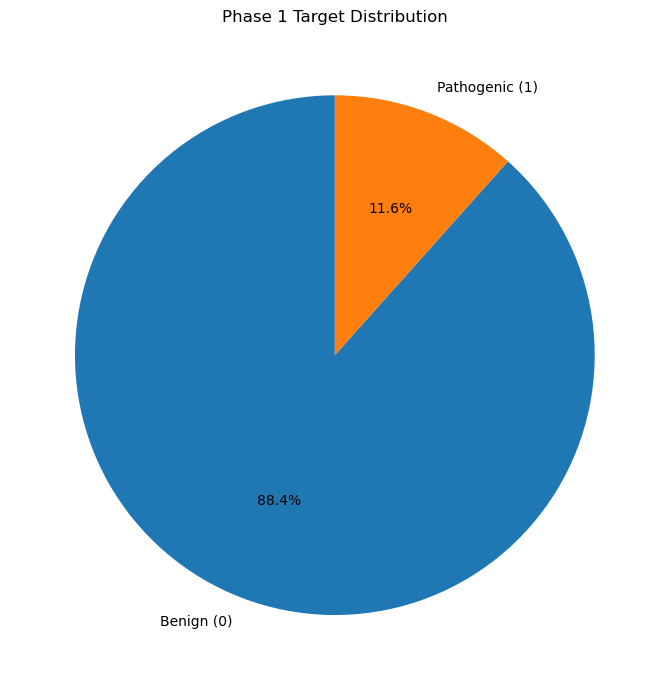

In [10]:
# VIZUALIZE THE TARGET DIDTRIBUTION

label_counts = phase1["label"].value_counts().sort_index()

labels = ["Benign (0)", "Pathogenic (1)"]
values = label_counts.to_numpy(dtype=float)

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Phase 1 Target Distribution")
plt.tight_layout()

plt.savefig(
    "../results/figures/phase1_target_distribution.png",
    dpi=300
)

plt.show()

In [11]:
# VARIANT TYPE DISTRIBUTION

phase1["variant_type"].value_counts()

variant_type
SNV    1396114
Name: count, dtype: int64

In [12]:
# RARE VARIANT DISTRIBUTION PERCENTAGE

rare_percentage = (
    phase1.groupby("label")["is_rare_variant"]
    .mean()
    .mul(100)
)

rare_percentage.index = ["Benign", "Pathogenic"]

rare_percentage

Benign        90.087083
Pathogenic    99.990124
Name: is_rare_variant, dtype: float64

In [13]:
# CORRELATION ANALYSIS --- POPULATION AND NUMERICAL FEATURE CORRELATION

correlation_features = [
    "af_tgp",
    "af_exac",
    "af_esp",
    "population_frequency_count",
    "max_population_af",
    "min_population_af",
    "mean_population_af",
    "ref_gc",
    "alt_gc",
    "consequence_count",
    "label"
]

correlation = phase1[correlation_features].corr()

correlation

,af_tgp,af_exac,af_esp,population_frequency_count,max_population_af,min_population_af,mean_population_af,ref_gc,alt_gc,consequence_count,label
af_tgp,1.000000,0.984742,0.985879,-0.183668,0.996797,0.995740,0.998030,-0.151484,0.146917,-0.079021,-0.033834
af_exac,0.984742,1.000000,0.990458,0.263780,0.993821,0.991852,0.996245,-0.078588,0.076856,-0.010150,-0.035312
af_esp,0.985879,0.990458,1.000000,0.177035,0.992501,0.994216,0.996352,-0.140166,0.138080,-0.025956,-0.034226
population_frequency_count,-0.183668,0.263780,0.177035,1.000000,0.027221,-0.014568,0.007746,0.044258,-0.057550,-0.032052,-0.199045
max_population_af,0.996797,0.993821,0.992501,0.027221,1.000000,0.993396,0.998462,-0.119646,0.118485,-0.071509,-0.051664
min_population_af,0.995740,0.991852,0.994216,-0.014568,0.993396,1.000000,0.998121,-0.119138,0.118102,-0.074925,-0.049463
mean_population_af,0.998030,0.996245,0.996352,0.007746,0.998462,0.998121,1.000000,-0.119617,0.118501,-0.073310,-0.050766
ref_gc,-0.151484,-0.078588,-0.140166,0.044258,-0.119646,-0.119138,-0.119617,1.000000,-0.688042,0.005894,0.032789
alt_gc,0.146917,0.076856,0.138080,-0.057550,0.118485,0.118102,0.118501,-0.688042,1.000000,-0.009310,-0.046556
consequence_count,-0.079021,-0.010150,-0.025956,-0.032052,-0.071509,-0.074925,-0.073310,0.005894,-0.009310,1.000000,0.036357


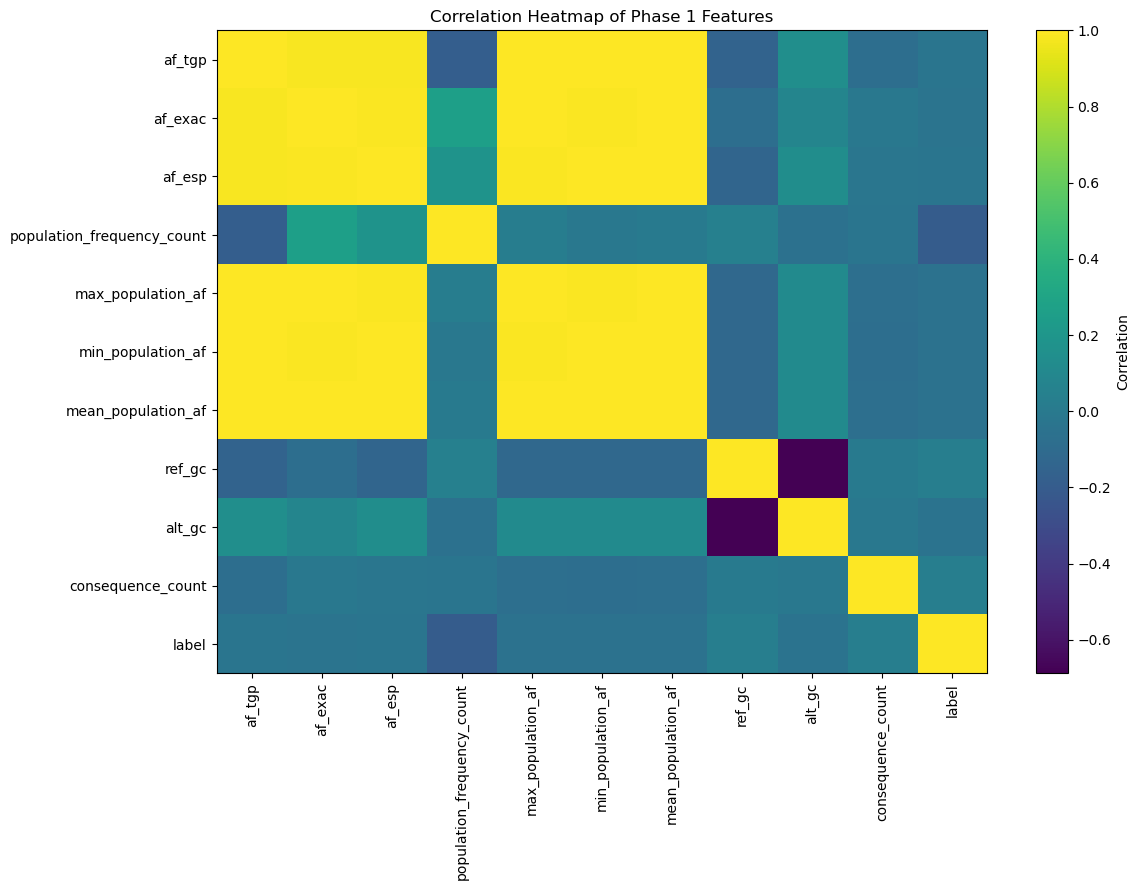

In [14]:
# VISUALIZE THE CORRELATION 

plt.figure(figsize=(12, 9))

plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Correlation")

labels = correlation.columns.tolist()
plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title("Correlation Heatmap of Phase 1 Features")
plt.tight_layout()

plt.savefig(
    "../results/figures/phase1_correlation_heatmap.png",
    dpi=300
)

plt.show()

#### Feature Engineering & Model Feature Selection

### Feature Groups

The Phase 1 model uses engineered numerical and binary features
representing:

1. Nucleotide-level characteristics
2. Molecular consequence categories
3. Functional impact
4. Population-frequency information
5. Variant rarity / population absence

In [15]:
# FINAL MODEL FEATURES

feature_columns = [
    "transition",
    "ref_gc",
    "alt_gc",
    "is_missense",
    "is_synonymous",
    "is_nonsense",
    "is_splice",
    "is_intronic",
    "is_utr",
    "is_noncoding",
    "is_protein_altering",
    "is_high_impact",
    "consequence_count",
    "population_frequency_count",
    "has_population_frequency",
    "max_population_af",
    "min_population_af",
    "mean_population_af",
    "is_rare_variant",
    "is_absent_from_population"
]

X = phase1[feature_columns]
y = phase1["label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1396114, 20)
Target: (1396114,)


In [16]:
# FEATURE CATEGORIES

feature_groups = {
    "Nucleotide": [
        "transition",
        "ref_gc",
        "alt_gc"
    ],
    "Molecular Consequence": [
        "is_missense",
        "is_synonymous",
        "is_nonsense",
        "is_splice",
        "is_intronic",
        "is_utr",
        "is_noncoding"
    ],
    "Functional Impact": [
        "is_protein_altering",
        "is_high_impact",
        "consequence_count"
    ],
    "Population Frequency": [
        "population_frequency_count",
        "has_population_frequency",
        "max_population_af",
        "min_population_af",
        "mean_population_af"
    ],
    "Variant Rarity": [
        "is_rare_variant",
        "is_absent_from_population"
    ]
}

for group, features in feature_groups.items():
    print(f"\n{group}:")
    for feature in features:
        print("  -", feature)


Nucleotide:
  - transition
  - ref_gc
  - alt_gc

Molecular Consequence:
  - is_missense
  - is_synonymous
  - is_nonsense
  - is_splice
  - is_intronic
  - is_utr
  - is_noncoding

Functional Impact:
  - is_protein_altering
  - is_high_impact
  - consequence_count

Population Frequency:
  - population_frequency_count
  - has_population_frequency
  - max_population_af
  - min_population_af
  - mean_population_af

Variant Rarity:
  - is_rare_variant
  - is_absent_from_population


#### Feature Validation

In [17]:
# DATA TYPES

X.dtypes

transition                       int8
ref_gc                           int8
alt_gc                           int8
is_missense                      int8
is_synonymous                    int8
is_nonsense                      int8
is_splice                        int8
is_intronic                      int8
is_utr                           int8
is_noncoding                     int8
is_protein_altering              int8
is_high_impact                   int8
consequence_count               int16
population_frequency_count       int8
has_population_frequency         int8
max_population_af             float64
min_population_af             float64
mean_population_af            float64
is_rare_variant                  int8
is_absent_from_population        int8
dtype: object

In [18]:
# MISSING VALUES

X.isna().sum().sort_values(ascending=False)

mean_population_af            884844
min_population_af             884844
max_population_af             884844
transition                         0
ref_gc                             0
is_rare_variant                    0
has_population_frequency           0
population_frequency_count         0
consequence_count                  0
is_high_impact                     0
is_protein_altering                0
is_noncoding                       0
is_utr                             0
is_intronic                        0
is_splice                          0
is_nonsense                        0
is_synonymous                      0
is_missense                        0
alt_gc                             0
is_absent_from_population          0
dtype: int64

In [19]:
# NUMERICAL SUMMARY

X.describe().T

,count,mean,std,min,25%,50%,75%,max
transition,1396114.0,0.696270,0.459868,0.0,0.00000,1.000000,1.00000,1.0
ref_gc,1396114.0,0.664168,0.472281,0.0,0.00000,1.000000,1.00000,1.0
alt_gc,1396114.0,0.385558,0.486727,0.0,0.00000,0.000000,1.00000,1.0
is_missense,1396114.0,0.140821,0.347837,0.0,0.00000,0.000000,0.00000,1.0
is_synonymous,1396114.0,0.470184,0.499110,0.0,0.00000,0.000000,1.00000,1.0
is_nonsense,1396114.0,0.045497,0.208392,0.0,0.00000,0.000000,0.00000,1.0
is_splice,1396114.0,0.026809,0.161524,0.0,0.00000,0.000000,0.00000,1.0
is_intronic,1396114.0,0.359067,0.479727,0.0,0.00000,0.000000,1.00000,1.0
is_utr,1396114.0,0.053357,0.224745,0.0,0.00000,0.000000,0.00000,1.0
is_noncoding,1396114.0,0.096411,0.295154,0.0,0.00000,0.000000,0.00000,1.0


In [20]:
# BINARY FEATURE VALIDATION

binary_features = [
    "transition",
    "is_missense",
    "is_synonymous",
    "is_nonsense",
    "is_splice",
    "is_intronic",
    "is_utr",
    "is_noncoding",
    "is_protein_altering",
    "is_high_impact",
    "has_population_frequency",
    "is_rare_variant",
    "is_absent_from_population"
]

for feature in binary_features:
    print(feature, ":", X[feature].dropna().unique())

transition : [1 0]
is_missense : [1 0]
is_synonymous : [0 1]
is_nonsense : [0 1]
is_splice : [0 1]
is_intronic : [0 1]
is_utr : [0 1]
is_noncoding : [0 1]
is_protein_altering : [1 0]
is_high_impact : [0 1]
has_population_frequency : [0 1]
is_rare_variant : [1 0]
is_absent_from_population : [1 0]


#### Train/Test Split

In [21]:
# SPLITTING DATASET INTO TRAINING AND TESTING DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1116891, 20)
Testing data: (279223, 20)


In [22]:
# SHOW TARGET DISTRIBUTION IN TRAIN/TEST

print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
label
0    987285
1    129606
Name: count, dtype: int64

Testing distribution:
label
0    246822
1     32401
Name: count, dtype: int64


#### Model Preprocessing

In [23]:
# MEDIAN IMPUTATION ---- FOR MODELS THAT DON'T HANDLE MISSING VALUES

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [24]:
# STANDARDIZATION FOR MLP

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#### Classical Machine Learning Models

## 9. Classical Machine Learning Models

Four classical machine learning algorithms are evaluated for
pathogenicity classification:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. HistGradientBoosting

All models are trained using the same training dataset and
evaluated on the same independent test dataset.

The models are compared using Accuracy, Precision, Recall,
F1-score, ROC-AUC, and PR-AUC.

In [25]:
# LOGISTIC REGRESSION ----
# It provides a simple linear reference against which more complexmachine learning models can be compared.


logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_imputed, y_train)

logistic_pred = logistic_model.predict(X_test_imputed)
logistic_prob = logistic_model.predict_proba(X_test_imputed)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [26]:
# RANDOM FOREST ----
# ensemble learning method that combines multiple decision trees to improve classification robustness and reduce overfitting.

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_imputed, y_train)

rf_pred = random_forest_model.predict(X_test_imputed)
rf_prob = random_forest_model.predict_proba(X_test_imputed)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [27]:
# GRADIENT BOOSTING ----
#Gradient Boosting builds an ensemble of decision trees sequentially, with each successive tree attempting to improve the errors made by the previous trees.

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train_imputed, y_train)

gb_pred = gradient_boosting_model.predict(X_test_imputed)
gb_prob = gradient_boosting_model.predict_proba(X_test_imputed)[:, 1]

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [28]:
# HISTGRADIENTBOOSTING ----
# HistGradientBoosting is an efficient gradient-boosting algorithm that uses histogram-based learning. It is included as a stronger tree-based candidate for the final Phase 1 model.

hist_gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.07,
    max_iter=180,
    max_leaf_nodes=63,
    l2_regularization=1.0,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)

hist_gradient_boosting_model.fit(X_train_imputed, y_train)

hist_pred = hist_gradient_boosting_model.predict(X_test_imputed)
hist_prob = hist_gradient_boosting_model.predict_proba(X_test_imputed)[:, 1]

print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


#### Classical Model Evaluation
### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Because the dataset contains substantially more benign than
pathogenic variants, Precision, Recall, F1-score, ROC-AUC and
PR-AUC are considered alongside accuracy.

In [29]:
# MODEL EVALUATION FUNCTION

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

In [30]:
# EVALUATE CLASSICAL MODELS


classical_results = []

classical_results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

classical_results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

classical_results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred,
        gb_prob
    )
)

classical_results.append(
    evaluate_model(
        "HistGradientBoosting",
        y_test,
        hist_pred,
        hist_prob
    )
)

classical_results_df = pd.DataFrame(classical_results)

classical_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.960505,0.875637,0.768834,0.818767,0.984631,0.915510
1,Random Forest,0.960845,0.875551,0.772353,0.820721,0.983590,0.916695
2,Gradient Boosting,0.960136,0.866851,0.775593,0.818687,0.984719,0.915010
3,HistGradientBoosting,0.960967,0.876726,0.772198,0.821149,0.985634,0.919178


#### Classification Reports
Detailed classification reports are generated for the four
classical machine learning models to examine class-wise
precision, recall and F1-score.

In [31]:
# 11.1 CLASSIFICATION REPORTS

classical_predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "HistGradientBoosting": hist_pred
}

for model_name, predictions in classical_predictions.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Benign", "Pathogenic"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98    246822
  Pathogenic       0.88      0.77      0.82     32401

    accuracy                           0.96    279223
   macro avg       0.92      0.88      0.90    279223
weighted avg       0.96      0.96      0.96    279223


Random Forest
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98    246822
  Pathogenic       0.88      0.77      0.82     32401

    accuracy                           0.96    279223
   macro avg       0.92      0.88      0.90    279223
weighted avg       0.96      0.96      0.96    279223


Gradient Boosting
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.98    246822
  Pathogenic       0.87      0.78      0.82     32401

    accuracy                           0.96    279223
   macro avg       0.92      0.88      0.90    279223
weighted avg       

#### Classical Model Comparison

In [32]:
# CLASSICAL MODEL COMPARISON TABLE

classical_comparison = classical_results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

classical_comparison[metric_columns] = (
    classical_comparison[metric_columns].round(4)
)

classical_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9605,0.8756,0.7688,0.8188,0.9846,0.9155
1,Random Forest,0.9608,0.8756,0.7724,0.8207,0.9836,0.9167
2,Gradient Boosting,0.9601,0.8669,0.7756,0.8187,0.9847,0.9150
3,HistGradientBoosting,0.9610,0.8767,0.7722,0.8211,0.9856,0.9192


# Deep Learning Model — MLP Neural Network

A feed-forward Multi-Layer Perceptron (MLP) neural network is
trained as the deep-learning comparison model.

The neural network uses the same Phase 1 feature set and the
same train/test partition used by the classical models.

### Architecture

20 Input Features ---        
Dense Layer — 64 neurons + ReLU ---
L2 Regularization --- 
Dense Layer — 32 neurons + ReLU ---
Output Layer — 1 neuron + Sigmoid

In [33]:
# MLP NEURAL NETWORK

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

print("=" * 70)
print("TRAINING MLP NEURAL NETWORK")
print("=" * 70)

mlp_model.fit(X_train_scaled, y_train)

print("\nTraining completed successfully.")
print("Number of iterations:", mlp_model.n_iter_)

TRAINING MLP NEURAL NETWORK
Iteration 1, loss = 0.09283803
Validation score: 0.961214
Iteration 2, loss = 0.08781000
Validation score: 0.961190
Iteration 3, loss = 0.08760922
Validation score: 0.961321
Iteration 4, loss = 0.08749016
Validation score: 0.961411
Iteration 5, loss = 0.08742979
Validation score: 0.961345
Iteration 6, loss = 0.08740125
Validation score: 0.957579
Iteration 7, loss = 0.08735612
Validation score: 0.961381
Iteration 8, loss = 0.08732746
Validation score: 0.961351
Iteration 9, loss = 0.08727295
Validation score: 0.961363
Iteration 10, loss = 0.08727987
Validation score: 0.961363
Iteration 11, loss = 0.08727231
Validation score: 0.961351
Iteration 12, loss = 0.08725076
Validation score: 0.961423
Iteration 13, loss = 0.08724328
Validation score: 0.961274
Iteration 14, loss = 0.08722347
Validation score: 0.961405
Iteration 15, loss = 0.08718312
Validation score: 0.961309
Iteration 16, loss = 0.08719635
Validation score: 0.961357
Iteration 17, loss = 0.08717502
Valid

In [34]:
#  MLP PREDICTIONS

mlp_pred = mlp_model.predict(X_test_scaled)

mlp_prob = mlp_model.predict_proba(
    X_test_scaled
)[:, 1]

print("MLP predictions generated successfully.")

MLP predictions generated successfully.


In [35]:
# MLP PERFORMANCE

mlp_results = evaluate_model(
    "MLP Neural Network",
    y_test,
    mlp_pred,
    mlp_prob
)

mlp_results_df = pd.DataFrame([mlp_results])

print("=" * 70)
print("MLP MODEL PERFORMANCE")
print("=" * 70)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]:
    print(
        f"{metric:<12}: "
        f"{mlp_results[metric]:.4f}"
    )

mlp_results_df

MLP MODEL PERFORMANCE
Accuracy    : 0.9608
Precision   : 0.8747
Recall      : 0.7725
F1 Score    : 0.8205
ROC-AUC     : 0.9852
PR-AUC      : 0.9182


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,MLP Neural Network,0.960766,0.874747,0.772507,0.820454,0.985243,0.918161


In [36]:
# MLP CLASSIFICATION REPORT

print(
    classification_report(
        y_test,
        mlp_pred,
        target_names=["Benign", "Pathogenic"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98    246822
  Pathogenic       0.87      0.77      0.82     32401

    accuracy                           0.96    279223
   macro avg       0.92      0.88      0.90    279223
weighted avg       0.96      0.96      0.96    279223



Confusion Matrix:
[[243238   3584]
 [  7371  25030]]


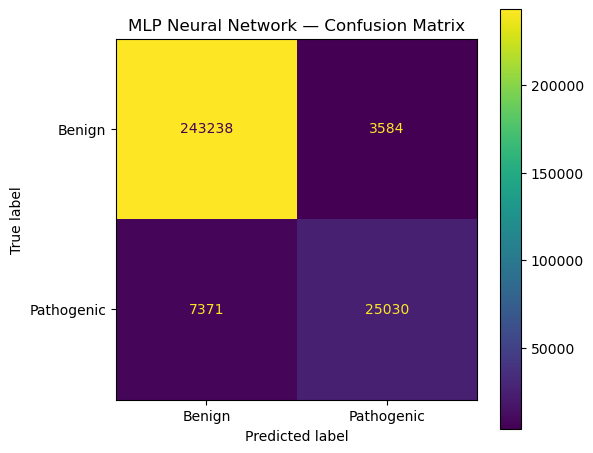

In [37]:
# MLP CONFUSION MATRIX

mlp_cm = confusion_matrix(y_test, mlp_pred)

print("Confusion Matrix:")
print(mlp_cm)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mlp_cm,
    display_labels=["Benign", "Pathogenic"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("MLP Neural Network — Confusion Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_mlp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

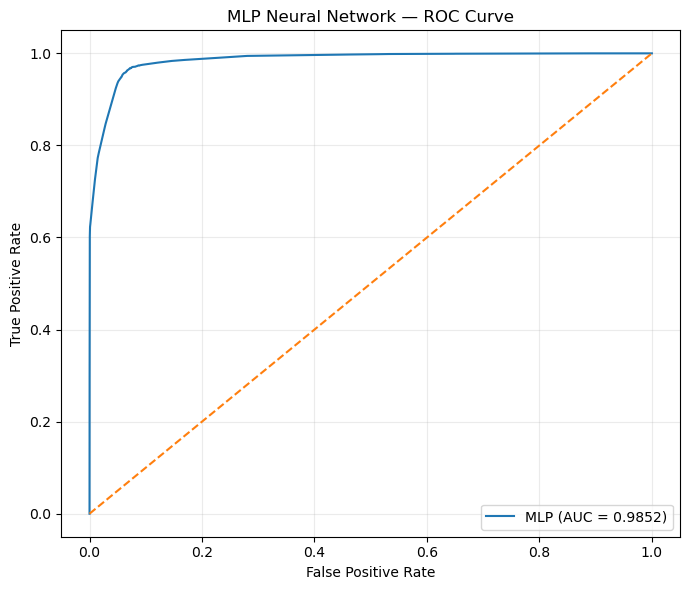

In [38]:
#  MLP ROC CURVE

mlp_fpr, mlp_tpr, _ = roc_curve(
    y_test,
    mlp_prob
)

mlp_roc_auc = auc(
    mlp_fpr,
    mlp_tpr
)

plt.figure(figsize=(7, 6))

plt.plot(
    mlp_fpr,
    mlp_tpr,
    label=f"MLP (AUC = {mlp_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP Neural Network — ROC Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_mlp_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

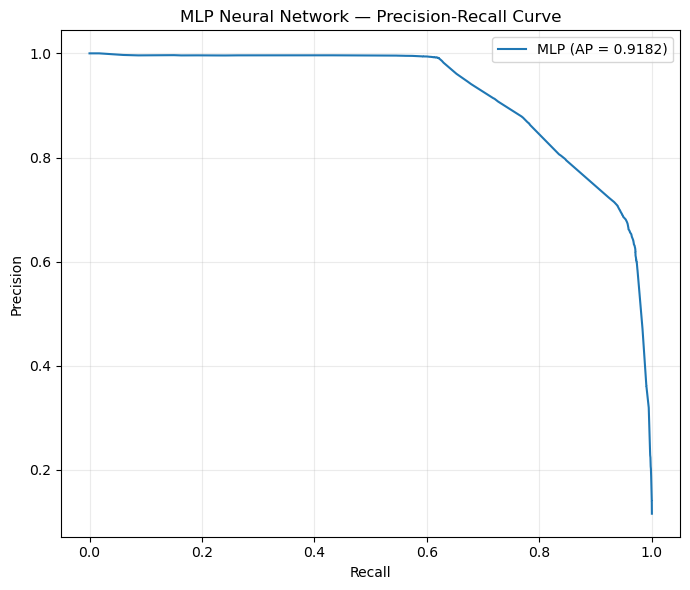

In [39]:
# MLP PRECISION-RECALL CURVE

mlp_precision, mlp_recall, _ = precision_recall_curve(
    y_test,
    mlp_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    mlp_recall,
    mlp_precision,
    label=f"MLP (AP = {mlp_results['PR-AUC']:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MLP Neural Network — Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_mlp_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

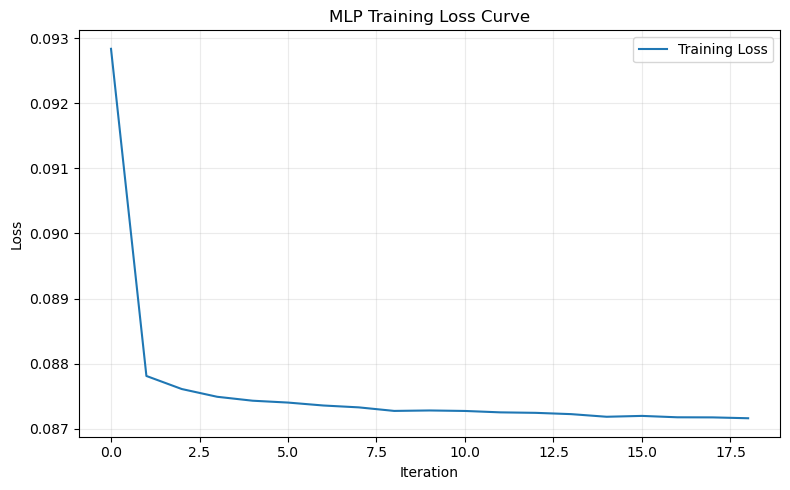

In [40]:
# MLP TRAINING LOSS

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model.loss_curve_,
    label="Training Loss"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_mlp_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Complete Model Comparison
The four classical machine learning models are compared with
the MLP neural network using the same test dataset and evaluation
metrics.

Models evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradientBoosting
- MLP Neural Networ

In [41]:
#  COMPLETE MODEL COMPARISON

all_results = pd.concat(
    [
        classical_results_df,
        mlp_results_df
    ],
    ignore_index=True
)

all_results[metric_columns] = (
    all_results[metric_columns].round(4)
)

all_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9605,0.8756,0.7688,0.8188,0.9846,0.9155
1,Random Forest,0.9608,0.8756,0.7724,0.8207,0.9836,0.9167
2,Gradient Boosting,0.9601,0.8669,0.7756,0.8187,0.9847,0.9150
3,HistGradientBoosting,0.9610,0.8767,0.7722,0.8211,0.9856,0.9192
4,MLP Neural Network,0.9608,0.8747,0.7725,0.8205,0.9852,0.9182


In [42]:
#  IDENTIFY BEST MODELS

print("Best model by Accuracy:")
print(
    all_results.loc[
        all_results["Accuracy"].idxmax()
    ]
)

print("\nBest model by F1 Score:")
print(
    all_results.loc[
        all_results["F1 Score"].idxmax()
    ]
)

print("\nBest model by ROC-AUC:")
print(
    all_results.loc[
        all_results["ROC-AUC"].idxmax()
    ]
)

print("\nBest model by PR-AUC:")
print(
    all_results.loc[
        all_results["PR-AUC"].idxmax()
    ]
)

Best model by Accuracy:
Model        HistGradientBoosting
Accuracy                    0.961
Precision                  0.8767
Recall                     0.7722
F1 Score                   0.8211
ROC-AUC                    0.9856
PR-AUC                     0.9192
Name: 3, dtype: object

Best model by F1 Score:
Model        HistGradientBoosting
Accuracy                    0.961
Precision                  0.8767
Recall                     0.7722
F1 Score                   0.8211
ROC-AUC                    0.9856
PR-AUC                     0.9192
Name: 3, dtype: object

Best model by ROC-AUC:
Model        HistGradientBoosting
Accuracy                    0.961
Precision                  0.8767
Recall                     0.7722
F1 Score                   0.8211
ROC-AUC                    0.9856
PR-AUC                     0.9192
Name: 3, dtype: object

Best model by PR-AUC:
Model        HistGradientBoosting
Accuracy                    0.961
Precision                  0.8767
Recall             

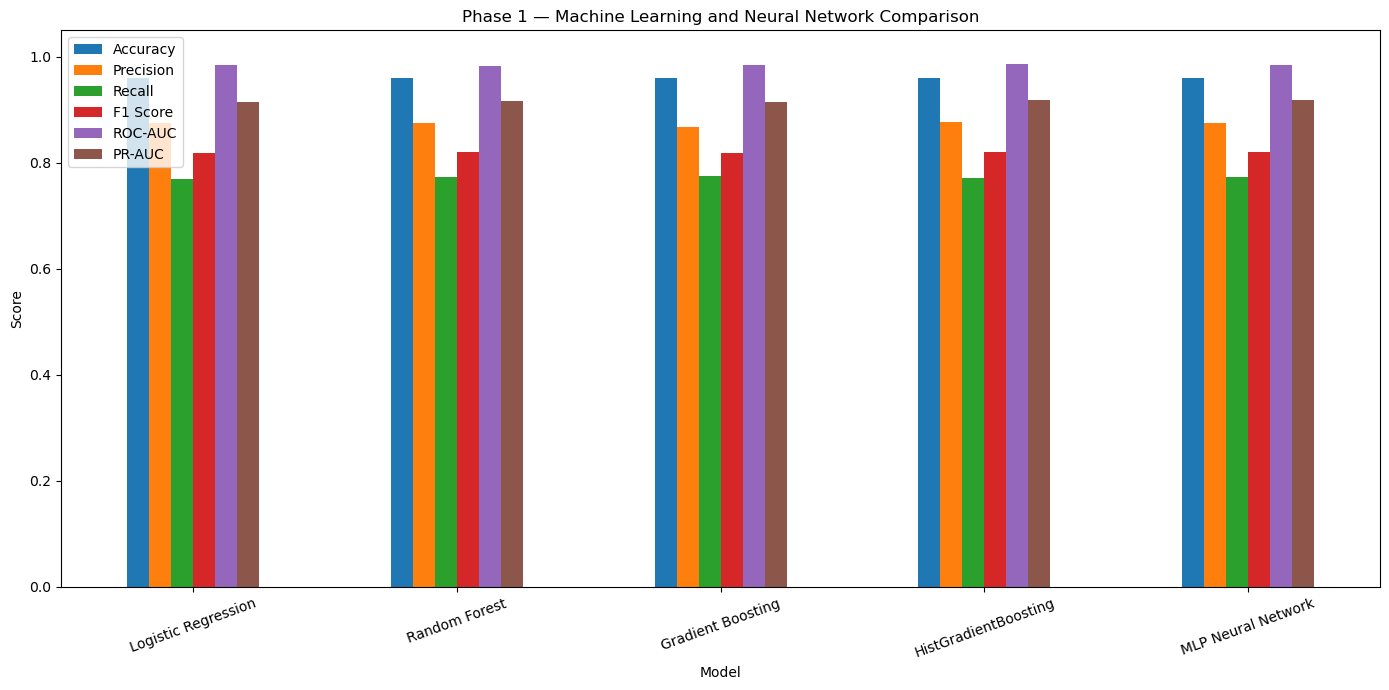

In [43]:
# COMPLETE MODEL COMPARISON PLOT

complete_comparison = all_results.set_index("Model")[metric_columns]

ax = complete_comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

ax.set_title(
    "Phase 1 — Machine Learning and Neural Network Comparison"
)

ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_complete_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Final Model Selection
Based on the comparative evaluation, HistGradientBoosting is
selected as the final Phase 1 model.

It provides the strongest overall combination of Accuracy,
Precision, Recall, F1-score, ROC-AUC and PR-AUC among the
evaluated models.

The MLP neural network achieved highly comparable performance,
supporting the use of both classical machine learning and
neural-network approaches in the Phase 1 study.

#### Final HstgradientBoosting Model

In [44]:
# FINAL HISTGRADIENTBOOSTING MODEL

final_model = HistGradientBoostingClassifier(
    learning_rate=0.07,
    max_iter=180,
    max_leaf_nodes=63,
    l2_regularization=1.0,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)

print("Training final HistGradientBoosting model...")

final_model.fit(
    X_train_imputed,
    y_train
)

print("Final model training completed.")

Training final HistGradientBoosting model...
Final model training completed.


#### Final Model Evaluation

In [45]:
#  FINAL MODEL PREDICTIONS

final_pred = final_model.predict(
    X_test_imputed
)

final_probabilities = final_model.predict_proba(
    X_test_imputed
)[:, 1]

print("Final predictions generated.")

Final predictions generated.


In [46]:
# FINAL MODEL METRICS

final_metrics = evaluate_model(
    "Final HistGradientBoosting",
    y_test,
    final_pred,
    final_probabilities
)

print("=" * 70)
print("FINAL PHASE 1 MODEL PERFORMANCE")
print("=" * 70)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]:
    print(
        f"{metric:<12}: "
        f"{final_metrics[metric]:.4f}"
    )

FINAL PHASE 1 MODEL PERFORMANCE
Accuracy    : 0.9610
Precision   : 0.8767
Recall      : 0.7722
F1 Score    : 0.8211
ROC-AUC     : 0.9856
PR-AUC      : 0.9192


#### Final Classification Report

In [47]:
#  FINAL CLASSIFICATION REPORT

print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Benign", "Pathogenic"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98    246822
  Pathogenic       0.88      0.77      0.82     32401

    accuracy                           0.96    279223
   macro avg       0.92      0.88      0.90    279223
weighted avg       0.96      0.96      0.96    279223



#### Final Confusion Matrix

Final Confusion Matrix:
[[243304   3518]
 [  7381  25020]]


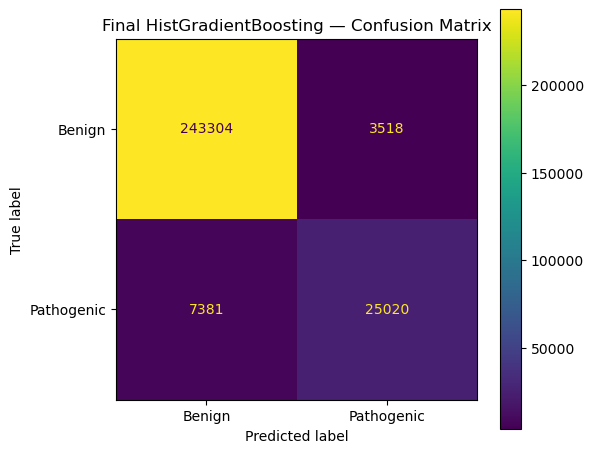

In [48]:
#  FINAL CONFUSION MATRIX

final_cm = confusion_matrix(
    y_test,
    final_pred
)

print("Final Confusion Matrix:")
print(final_cm)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Benign", "Pathogenic"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Final HistGradientBoosting — Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Final ROC Curve

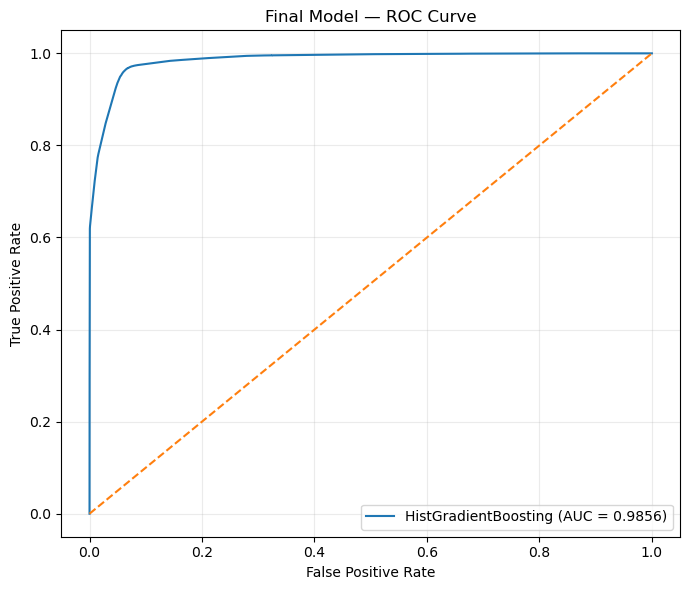

In [49]:
# FINAL ROC CURVE

final_fpr, final_tpr, _ = roc_curve(
    y_test,
    final_probabilities
)

final_roc_auc = auc(
    final_fpr,
    final_tpr
)

plt.figure(figsize=(7, 6))

plt.plot(
    final_fpr,
    final_tpr,
    label=f"HistGradientBoosting (AUC = {final_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model — ROC Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_final_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Final Precision-Recall Curve

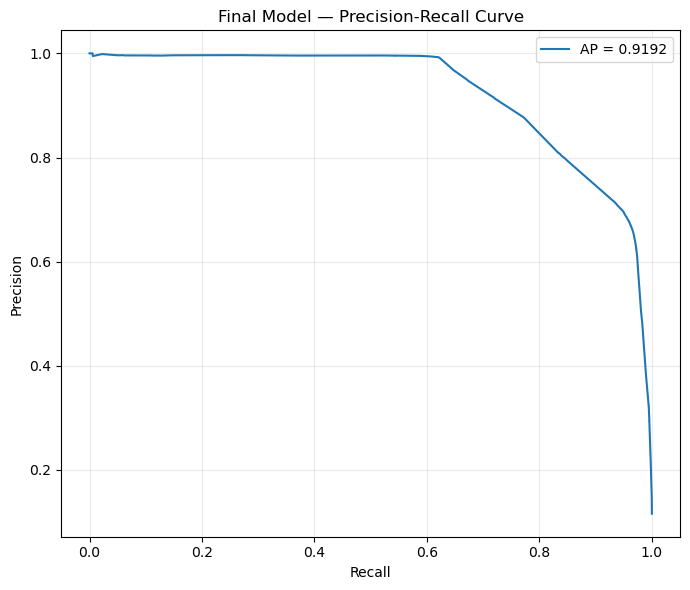

In [50]:
#  FINAL PRECISION-RECALL CURVE

final_precision, final_recall, _ = precision_recall_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7, 6))

plt.plot(
    final_recall,
    final_precision,
    label=f"AP = {final_metrics['PR-AUC']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Model — Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_final_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Model Explainability
Permutation feature importance is used to estimate the influence
of each selected feature on the final HistGradientBoosting model.

A feature is considered important when randomly permuting its
values causes a measurable decrease in model performance.

In [51]:

# PERMUTATION FEATURE IMPORTANCE


print("Calculating permutation feature importance...")

permutation_result = permutation_importance(
    final_model,
    X_test_imputed,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_Std": permutation_result.importances_std
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_df

Calculating permutation feature importance...


,Feature,Importance_Mean,Importance_Std
0,is_high_impact,8.302909e-02,0.000365
1,is_synonymous,5.160089e-02,0.000461
2,is_missense,1.298118e-02,0.000094
3,is_intronic,1.035830e-02,0.000079
4,population_frequency_count,5.071484e-03,0.000217
5,max_population_af,4.037056e-03,0.000206
6,transition,2.016471e-03,0.000075
7,consequence_count,1.923282e-03,0.000066
8,mean_population_af,8.514668e-04,0.000089
9,is_noncoding,7.268518e-04,0.000022


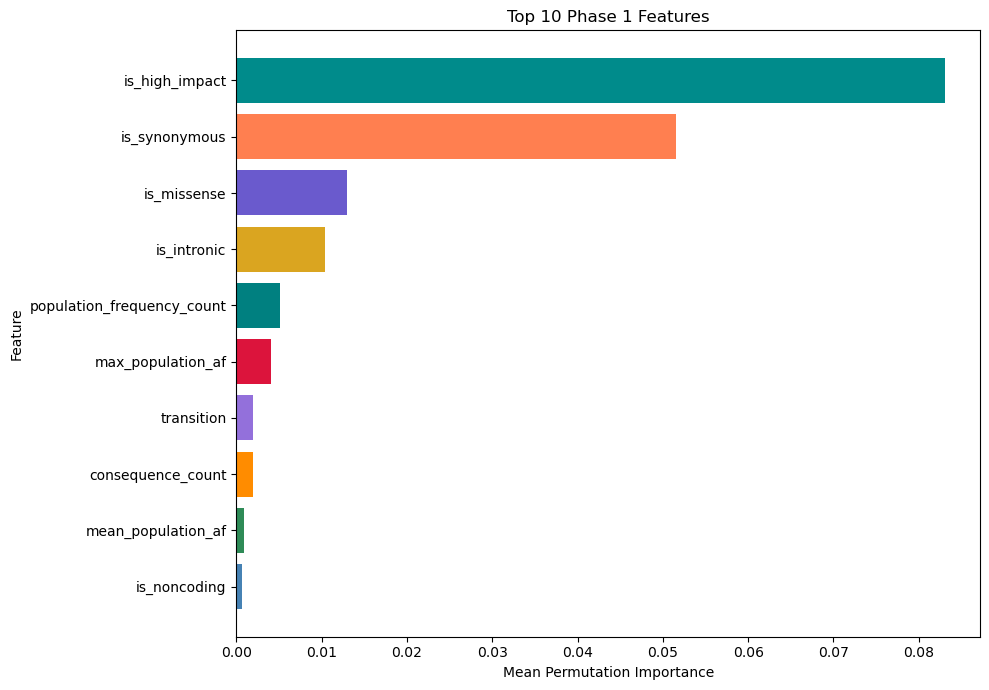

Top 10 features:
                      Feature  Importance_Mean  Importance_Std
0              is_high_impact         0.083029        0.000365
1               is_synonymous         0.051601        0.000461
2                 is_missense         0.012981        0.000094
3                 is_intronic         0.010358        0.000079
4  population_frequency_count         0.005071        0.000217
5           max_population_af         0.004037        0.000206
6                  transition         0.002016        0.000075
7           consequence_count         0.001923        0.000066
8          mean_population_af         0.000851        0.000089
9                is_noncoding         0.000727        0.000022


In [52]:
# TOP 10 FEATURE IMPORTANCE

top_features = feature_importance_df.head(10)

features = top_features["Feature"].astype(str).to_numpy()[::-1]
importance = top_features["Importance_Mean"].to_numpy(dtype=float)[::-1]

# Different color for each feature
colors = [
    "steelblue",
    "seagreen",
    "darkorange",
    "mediumpurple",
    "crimson",
    "teal",
    "goldenrod",
    "slateblue",
    "coral",
    "darkcyan"
]

plt.figure(figsize=(10, 7))

plt.barh(
    features,
    importance,
    color=colors
)

plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Phase 1 Features")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase1_top10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top 10 features:")
print(top_features)

#### Generate Final Predictions
The final Phase 1 model is used to generate pathogenicity
probabilities and predicted classifications for the held-out
test records.

The probability represents the model's estimated probability
for the pathogenic class.

In [53]:
#  FINAL PREDICTIONS

phase1_predictions = phase1.loc[
    X_test.index
].copy()

phase1_predictions["Pathogenicity_Probability"] = (
    final_probabilities
)

phase1_predictions["Pathogenicity_Category"] = np.where(
    final_probabilities >= 0.5,
    "Pathogenic",
    "Benign"
)

print("Final prediction dataset created.")

phase1_predictions[
    [
        "Pathogenicity_Probability",
        "Pathogenicity_Category"
    ]
].head()

Final prediction dataset created.


,Pathogenicity_Probability,Pathogenicity_Category
1128607,0.009462,Benign
1325777,0.270594,Benign
1024672,0.000573,Benign
999557,0.000920,Benign
1126384,0.001853,Benign


#### Save Models, Metrics and Prediction Outputs
The trained models, evaluation metrics, feature-importance
results and final predictions are exported so that the Phase 1
results can be reproduced and used by downstream components of
the Genetic Risk Prediction system.

In [54]:
# SAVE FINAL MODEL

final_model_path = (
    MODELS_DIR /
    "phase1_histgradientboosting_final.joblib"
)

joblib.dump(
    final_model,
    final_model_path
)

print("Final model saved to:")
print(final_model_path)

Final model saved to:
..\models\phase1\phase1_histgradientboosting_final.joblib


In [55]:
# SAVE MLP MODEL

mlp_model_path = (
    MODELS_DIR /
    "phase1_mlp_model.joblib"
)

mlp_scaler_path = (
    MODELS_DIR /
    "phase1_mlp_scaler.joblib"
)

joblib.dump(
    mlp_model,
    mlp_model_path
)

joblib.dump(
    scaler,
    mlp_scaler_path
)

print("MLP model saved.")
print("MLP model:", mlp_model_path)
print("MLP scaler:", mlp_scaler_path)

MLP model saved.
MLP model: ..\models\phase1\phase1_mlp_model.joblib
MLP scaler: ..\models\phase1\phase1_mlp_scaler.joblib


In [56]:
# SAVE MODEL COMPARISON METRICS


comparison_path = (
    METRICS_DIR /
    "phase1_model_comparison.csv"
)

all_results.to_csv(
    comparison_path,
    index=False
)

final_metrics_path = (
    METRICS_DIR /
    "phase1_final_metrics.json"
)

with open(
    final_metrics_path,
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

mlp_metrics_path = (
    METRICS_DIR /
    "phase1_mlp_metrics.json"
)

with open(
    mlp_metrics_path,
    "w"
) as f:

    json.dump(
        mlp_results,
        f,
        indent=4
    )

print("Metrics saved successfully.")

Metrics saved successfully.


In [57]:
# SAVE FEATURE IMPORTANCE

feature_importance_path = (
    METRICS_DIR /
    "phase1_feature_importance.csv"
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print(
    "Feature importance saved to:",
    feature_importance_path
)

Feature importance saved to: ..\results\metrics\phase1_feature_importance.csv


In [58]:
# SAVE FINAL PREDICTIONS


prediction_path = (
    PREDICTIONS_DIR /
    "phase1_final_predictions.parquet"
)

phase1_predictions.to_parquet(
    prediction_path,
    index=False
)

print(
    "Predictions saved to:",
    prediction_path
)

Predictions saved to: ..\results\predictions\phase1_final_predictions.parquet


####  Phase 1 — Final Summary
Phase 1 developed a pathogenicity classification pipeline using
1,396,114 genetic variant records and 20 selected variant-level
and population-based features.

Four classical machine-learning models and one neural-network
model were evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradientBoosting
- MLP Neural Network

The final HistGradientBoosting model achieved:

- Accuracy: 96.09%
- Precision: 87.68%
- Recall: 77.18%
- F1-score: 82.09%
- ROC-AUC: 98.56%
- PR-AUC: 91.88%

The MLP neural network achieved:

- Accuracy: 96.08%
- Precision: 87.47%
- Recall: 77.25%
- F1-score: 82.05%
- ROC-AUC: 98.52%
- PR-AUC: 91.82%

HistGradientBoosting was selected as the final Phase 1 model
because it achieved the strongest overall performance across
the evaluated metrics.

The MLP produced highly comparable results and demonstrates the
applicability of a neural-network approach to the same
classification problem.

The final Phase 1 model, metrics, feature-importance results and
prediction outputs were exported for reproducibility and
downstream integration with Phase 2 inheritance analysis.